# Clustering Experiments

This notebook is focused on exploratory clustering work only:
- skewness checks and transformations
- PCA diagnostics and interpretation
- k selection via elbow and silhouette
- cluster interpretation

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as PCA_viz

candidate_paths = [
    Path("data/processed/geometry_metric_features_4115chips.csv"),
    Path("../data/processed/geometry_metric_features_4115chips.csv"),
]

resolved_csv = next((p.resolve() for p in candidate_paths if p.exists()), None)
if resolved_csv is None:
    tried = "\n".join(str(p.resolve()) for p in candidate_paths)
    raise FileNotFoundError(
        f"Could not find geometry CSV. Current working directory: {Path.cwd()}\nTried:\n{tried}"
    )

df = pd.read_csv(resolved_csv)
print(f"Loaded {len(df)} rows and {len(df.columns)} columns from {resolved_csv}")
display(df.head())

Loaded 4115 rows and 18 columns from /Users/fidaa/geofarmer-project/data/processed/geometry_metric_features_4115chips.csv


,chip_id,country,num_fields,mean_area,mean_area_sqm,mean_area_px,area_cv,coverage,fields_per_covered_area,mean_aspect_ratio,largest_field_fraction,mean_compactness,mean_rectangularity,std_rectangularity,prop_rectangular_07,mean_edge_density,mean_cardinal_alignment,median_cardinal_alignment
0,g0_0000002048-0000012288,kenya,1,395.608565,395.608565,11.0,0.0,0.000168,0.002528,0.867217,1.0,1.000000,0.687500,0.0,0.0,0.877896,0.867217,0.867217
1,g0_0000005632-0000006144,kenya,1,719.186866,719.186866,20.0,0.0,0.000305,0.001390,0.745230,1.0,0.994199,0.476190,0.0,0.0,0.794975,0.685847,0.685847
2,g0_0000007680-0000002048,kenya,1,431.474394,431.474394,12.0,0.0,0.000183,0.002318,0.658074,1.0,1.000000,0.800000,0.0,1.0,0.801777,1.034070,1.034070
3,g10_0000008192-0000002048,kenya,1,1187.788251,1187.788251,33.0,0.0,0.000504,0.000842,0.411349,1.0,0.822813,0.660000,0.0,0.0,0.680295,0.881426,0.881426
4,g10_0000009728-0000004608,kenya,1,611.960472,611.960472,17.0,0.0,0.000259,0.001634,0.495074,1.0,1.000000,0.809524,0.0,1.0,0.730248,1.065033,1.065033


## Baseline: Raw Features (No Preprocessing)
This demonstrates why preprocessing and feature selection are critical.

All numeric columns (16):
['num_fields', 'mean_area', 'mean_area_sqm', 'mean_area_px', 'area_cv', 'coverage', 'fields_per_covered_area', 'mean_aspect_ratio', 'largest_field_fraction', 'mean_compactness', 'mean_rectangularity', 'std_rectangularity', 'prop_rectangular_07', 'mean_edge_density', 'mean_cardinal_alignment', 'median_cardinal_alignment']


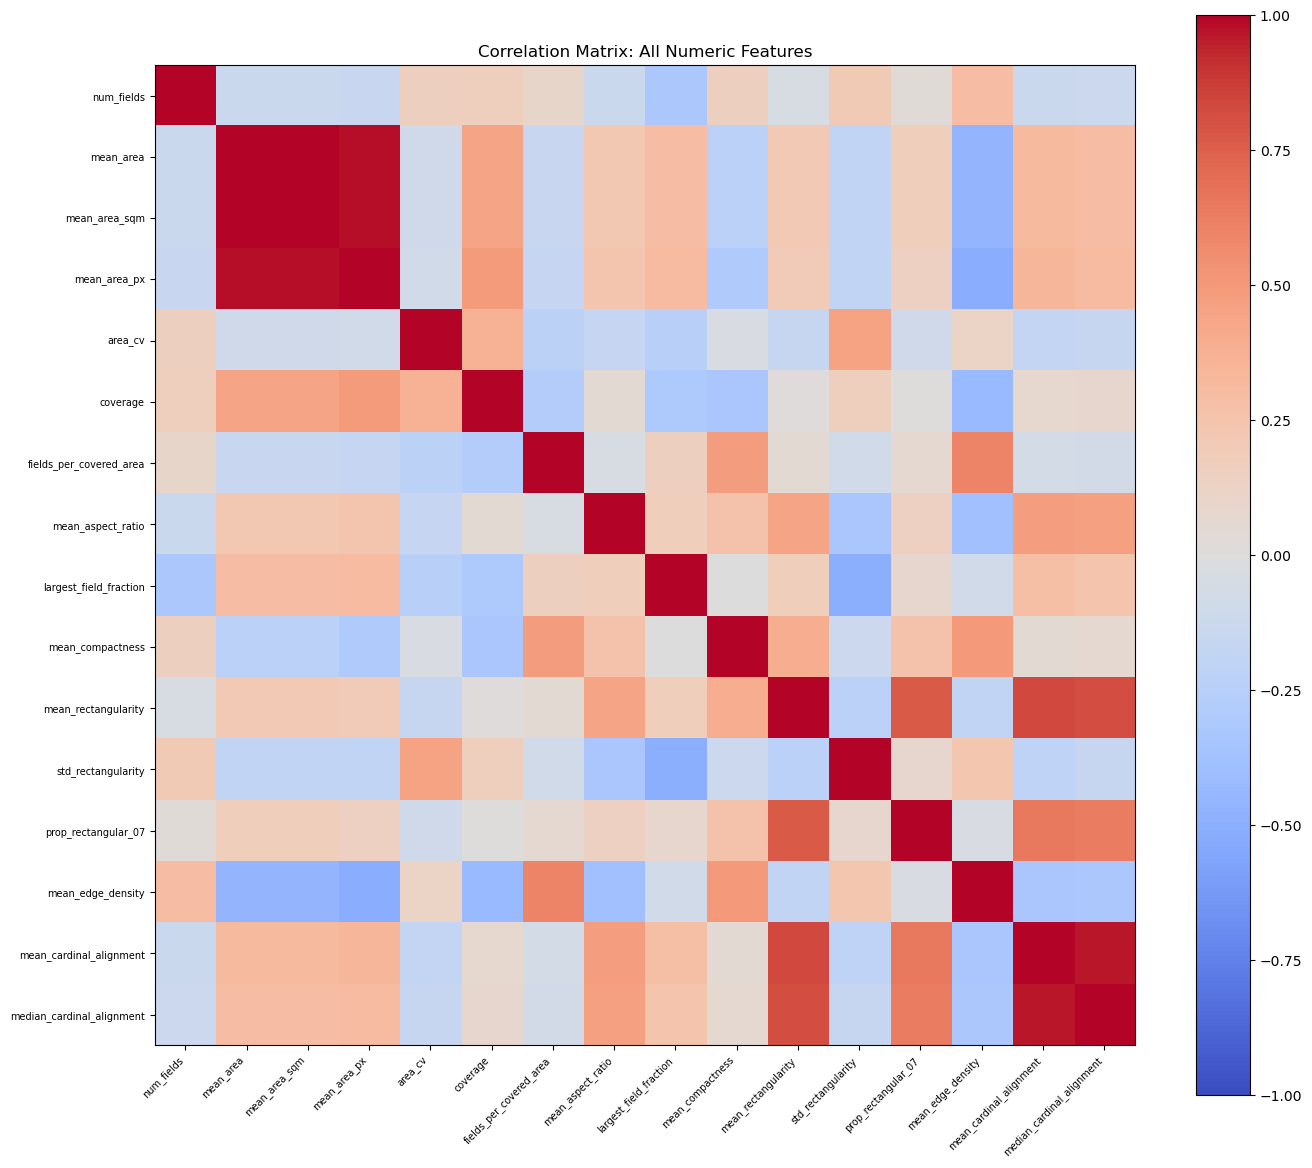

In [20]:
# Correlation matrix: all numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"All numeric columns ({len(numeric_cols)}):")
print(numeric_cols)

corr_all_numeric = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_all_numeric, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(numeric_cols, fontsize=7)
plt.title("Correlation Matrix: All Numeric Features")
plt.tight_layout()
plt.show()

Raw feature matrix shape: (4115, 16)


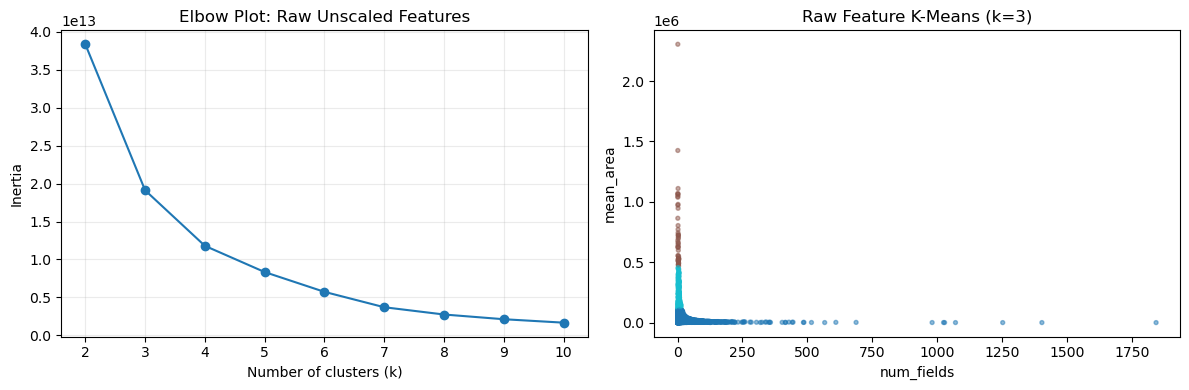

Raw feature clustering - cluster sizes:
0    3600
1      49
2     466
Name: count, dtype: int64


In [21]:
# K-Means on original (unscaled) numeric features as baseline
raw_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_raw = df[raw_numeric_cols].apply(pd.to_numeric, errors='coerce')
valid_raw_idx = X_raw.dropna().index
X_raw_valid = X_raw.loc[valid_raw_idx].values

print(f'Raw feature matrix shape: {X_raw_valid.shape}')

# Elbow on raw features
k_values_raw = list(range(2, 11))
inertias_raw = []
for k in k_values_raw:
    km_raw = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=200)
    km_raw.fit(X_raw_valid)
    inertias_raw.append(km_raw.inertia_)

# Fit final raw model
km_raw_final = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_raw = km_raw_final.fit_predict(X_raw_valid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values_raw, inertias_raw, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot: Raw Unscaled Features')
axes[0].grid(alpha=0.25)

# Plot in 2D using first two raw features
axes[1].scatter(X_raw_valid[:, 0], X_raw_valid[:, 1], c=labels_raw, s=8, alpha=0.5, cmap='tab10')
axes[1].set_xlabel(raw_numeric_cols[0])
axes[1].set_ylabel(raw_numeric_cols[1])
axes[1].set_title('Raw Feature K-Means (k=3)')

plt.tight_layout()
plt.show()

print(f'Raw feature clustering - cluster sizes:')
print(pd.Series(labels_raw).value_counts().sort_index())

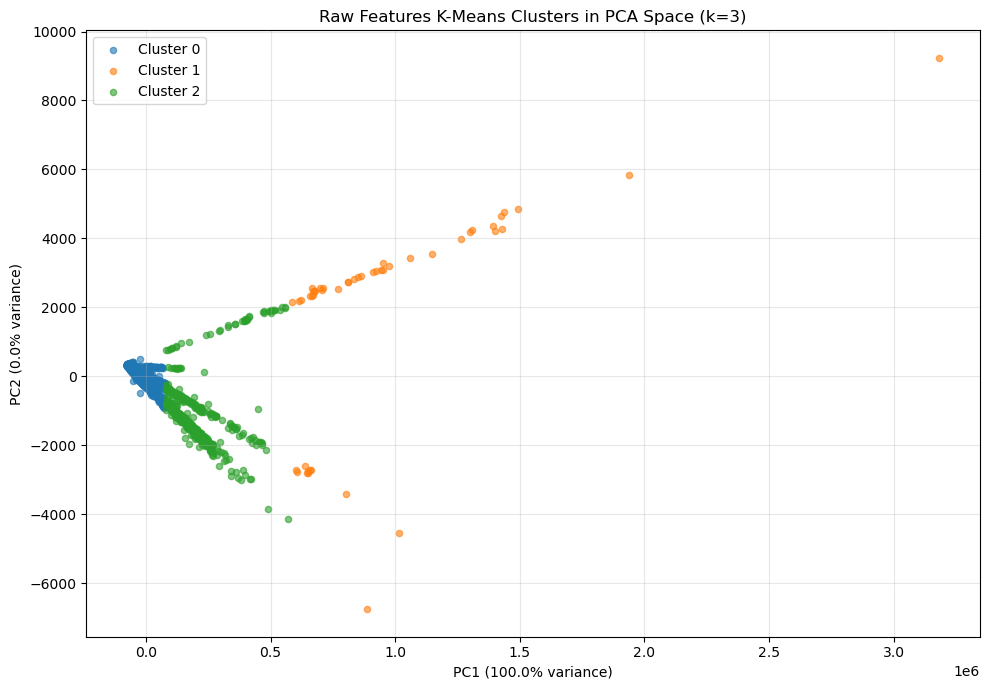


Raw features PCA explains 100.0% of variance in 2D


In [22]:
# Visualize raw clusters in 2D PCA projection
# Apply PCA to raw features for visualization
pca_raw = PCA_viz(n_components=2, random_state=42)
X_raw_2d = pca_raw.fit_transform(X_raw_valid)

plt.figure(figsize=(10, 7))
for cl in sorted(np.unique(labels_raw)):
    mask = labels_raw == cl
    plt.scatter(X_raw_2d[mask, 0], X_raw_2d[mask, 1], s=20, alpha=0.6, label=f'Cluster {cl}')

plt.xlabel(f'PC1 ({pca_raw.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_raw.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Raw Features K-Means Clusters in PCA Space (k=3)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nRaw features PCA explains {pca_raw.explained_variance_ratio_.sum():.1%} of variance in 2D')

## Investigation: Skewness, Transformations & Feature Selection
Exploring data characteristics and justifying feature choices.

Skewness (raw features):


,skew
num_fields,13.784587
fields_per_covered_area,10.803924
mean_area_sqm,6.993942


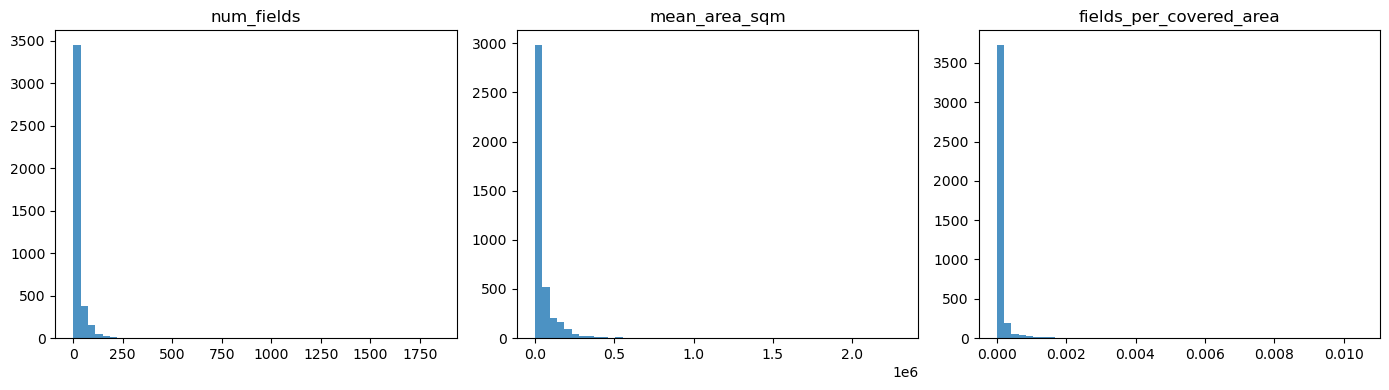

In [23]:
# Skewness check before transformation
raw_cols = ["num_fields", "mean_area_sqm", "fields_per_covered_area"]
raw_skew = df[raw_cols].skew().sort_values(ascending=False)
print("Skewness (raw features):")
display(raw_skew.to_frame("skew"))

fig, axes = plt.subplots(1, len(raw_cols), figsize=(14, 4))
for i, col in enumerate(raw_cols):
    axes[i].hist(df[col].dropna(), bins=50, alpha=0.8)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [24]:
# Log transforms used in model training/inference scripts
df["log_num_fields"] = np.log1p(df["num_fields"])
df["log_mean_area_sqm"] = np.log1p(df["mean_area_sqm"])
df["log_fields_per_covered_area"] = np.log1p(df["fields_per_covered_area"] * 1e6)

log_cols = ["log_num_fields", "log_mean_area_sqm", "log_fields_per_covered_area"]
log_skew = df[log_cols].skew().sort_values(ascending=False)
print("Skewness (log-transformed features):")
display(log_skew.to_frame("skew"))

Skewness (log-transformed features):


,skew
log_num_fields,0.436636
log_fields_per_covered_area,0.354048
log_mean_area_sqm,-0.189230


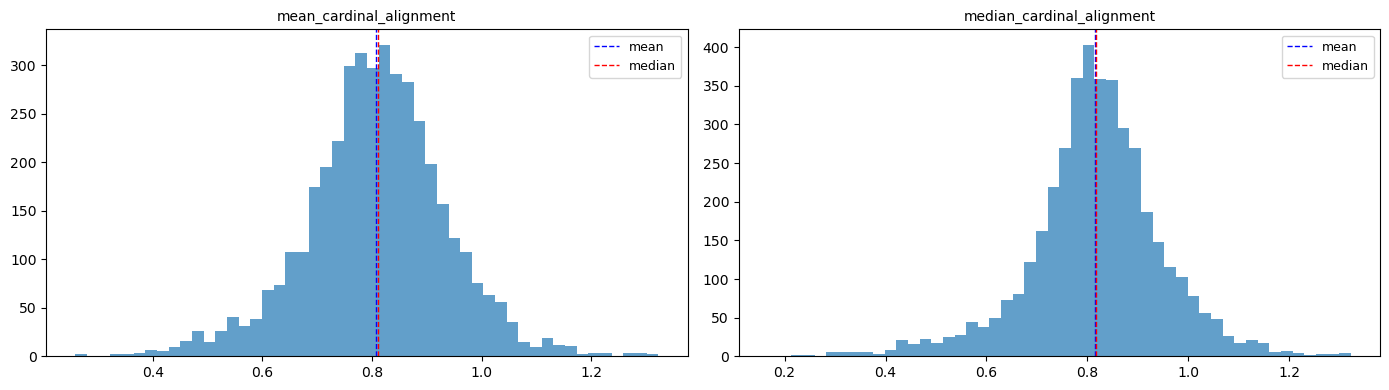

Correlation between mean and median cardinal alignment:


,mean_cardinal_alignment,median_cardinal_alignment
mean_cardinal_alignment,1.000000,0.963261
median_cardinal_alignment,0.963261,1.000000


In [25]:
# Check if mean_cardinal_alignment and median_cardinal_alignment are redundant
if 'median_cardinal_alignment' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    features_to_check = ['mean_cardinal_alignment', 'median_cardinal_alignment']
    for ax, col in zip(axes, features_to_check):
        ax.hist(df[col].dropna(), bins=50, edgecolor='none', alpha=0.7)
        ax.axvline(df[col].mean(), color='blue', linestyle='--', linewidth=1, label='mean')
        ax.axvline(df[col].median(), color='red', linestyle='--', linewidth=1, label='median')
        ax.set_title(col, fontsize=10)
        ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    corr_cardinals = df[['mean_cardinal_alignment', 'median_cardinal_alignment']].corr()
    print('Correlation between mean and median cardinal alignment:')
    display(corr_cardinals)
else:
    print('median_cardinal_alignment not found in data; proceeding with mean only')

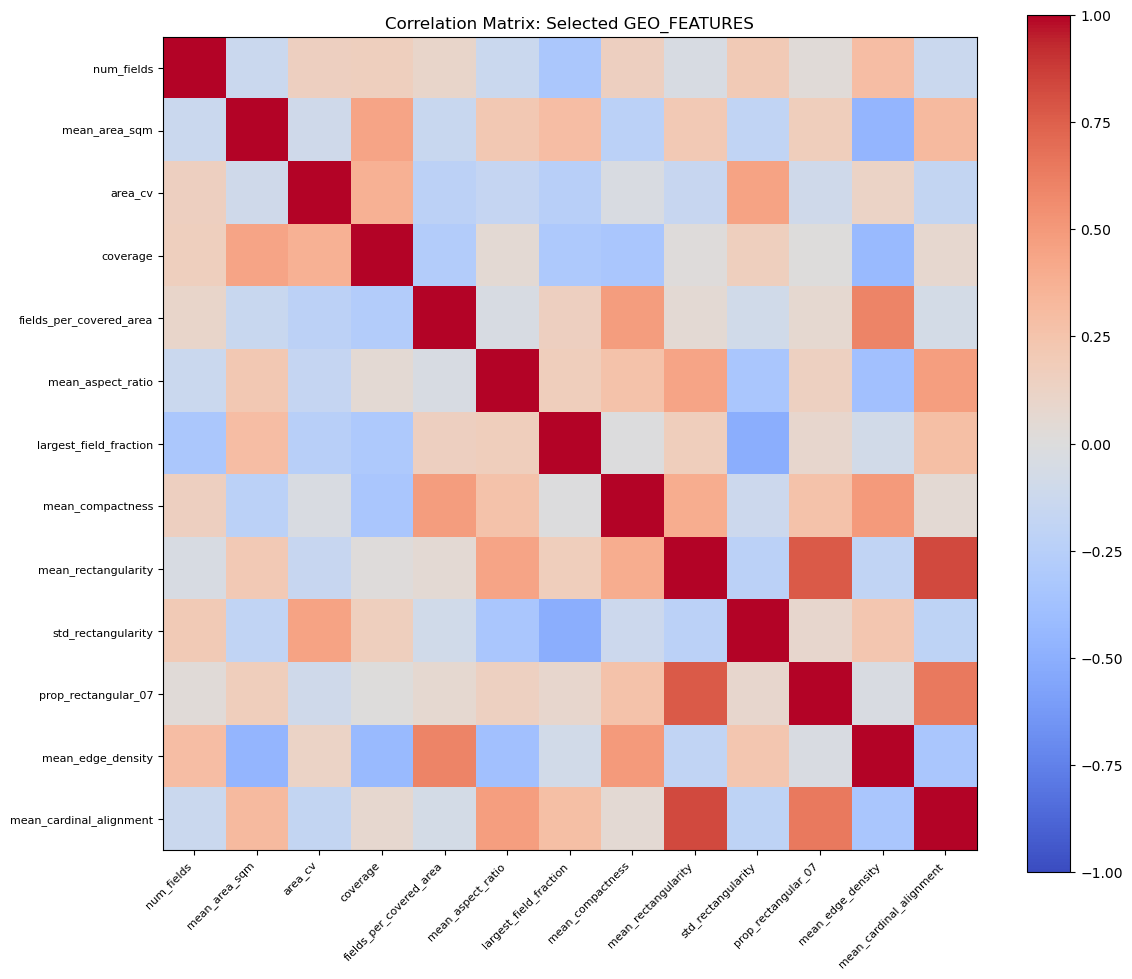

In [26]:
# Correlation matrix: selected GEO_FEATURES
all_geo = [
    'num_fields', 'mean_area_sqm', 'area_cv', 'coverage',
    'fields_per_covered_area', 'mean_aspect_ratio', 'largest_field_fraction',
    'mean_compactness', 'mean_rectangularity', 'std_rectangularity',
    'prop_rectangular_07', 'mean_edge_density', 'mean_cardinal_alignment',
]

corr_geo = df[all_geo].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_geo, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(all_geo)))
ax.set_yticks(range(len(all_geo)))
ax.set_xticklabels(all_geo, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(all_geo, fontsize=8)
plt.title('Correlation Matrix: Selected GEO_FEATURES')
plt.tight_layout()
plt.show()

## Standardization & Feature Extraction
Preparing data for clustering via standardization and dimensionality reduction.

In [27]:
GEO_FEATURES = [
    "log_num_fields", "log_mean_area_sqm", "area_cv", "coverage",
    "log_fields_per_covered_area", "mean_aspect_ratio", "largest_field_fraction",
    "mean_compactness", "mean_rectangularity", "std_rectangularity",
    "prop_rectangular_07", "mean_edge_density", "mean_cardinal_alignment",
]

X = StandardScaler().fit_transform(df[GEO_FEATURES])
print(f"Standardized feature matrix shape: {X.shape}")

Standardized feature matrix shape: (4115, 13)


### Principal Component Analysis (PCA)
Extracting principal components and analyzing their contribution.

In [28]:
# PCA fitting and dimensionality selection
pca_full = PCA(random_state=42)
pca_full.fit(X)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.argmax(cum_var >= 0.90) + 1)

pca = PCA(n_components=n_components_90, random_state=42)
X_pca = pca.fit_transform(X)
X_pca_2d = X_pca[:, :2]

print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_pca.shape}")
print(f"Components for >=90% variance: {n_components_90}")
print(f"Explained variance by reduced set: {pca.explained_variance_ratio_.sum():.2%}")

Original shape: (4115, 13)
Reduced shape: (4115, 6)
Components for >=90% variance: 6
Explained variance by reduced set: 91.95%


In [29]:
# PCA loadings for interpretation
loadings = pd.DataFrame(
    pca.components_.T,
    index=GEO_FEATURES,
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)]
)
display(loadings)

top_k = 4
for pc in loadings.columns:
    print(f"\nTop {top_k} features for {pc} (absolute loading):")
    top = loadings[pc].abs().sort_values(ascending=False).head(top_k).index
    display(loadings.loc[top, [pc]].sort_values(by=pc, ascending=False))

,PC1,PC2,PC3,PC4,PC5,PC6
log_num_fields,-0.268252,-0.287469,-0.367632,-0.199262,-0.138128,0.176988
log_mean_area_sqm,0.413460,-0.282867,0.029476,0.022538,0.075136,-0.004941
area_cv,-0.097179,-0.291545,-0.254947,0.029670,0.759507,-0.037348
coverage,0.181732,-0.380053,-0.230548,-0.153669,0.064071,0.442912
log_fields_per_covered_area,-0.410969,0.289094,-0.029096,-0.020018,-0.072409,0.017621
mean_aspect_ratio,0.263319,0.170489,-0.109317,-0.618404,0.095100,-0.517455
largest_field_fraction,0.207321,0.268376,0.336911,0.272938,0.501309,0.056250
mean_compactness,-0.165398,0.353643,-0.247871,-0.386703,0.250485,0.091626
mean_rectangularity,0.246439,0.303654,-0.415361,0.038401,-0.019643,0.158667
std_rectangularity,-0.198861,-0.252503,-0.297835,0.360176,-0.012639,-0.662908



Top 4 features for PC1 (absolute loading):


,PC1
log_mean_area_sqm,0.413460
mean_cardinal_alignment,0.335294
log_fields_per_covered_area,-0.410969
mean_edge_density,-0.413530



Top 4 features for PC2 (absolute loading):


,PC2
mean_compactness,0.353643
mean_rectangularity,0.303654
area_cv,-0.291545
coverage,-0.380053


...

,PC4
prop_rectangular_07,0.392312
std_rectangularity,0.360176
mean_compactness,-0.386703
mean_aspect_ratio,-0.618404



Top 4 features for PC5 (absolute loading):


,PC5
area_cv,0.759507
largest_field_fraction,0.501309
mean_compactness,0.250485
mean_edge_density,0.229851



Top 4 features for PC6 (absolute loading):


,PC6
coverage,0.442912
log_num_fields,0.176988
mean_aspect_ratio,-0.517455
std_rectangularity,-0.662908


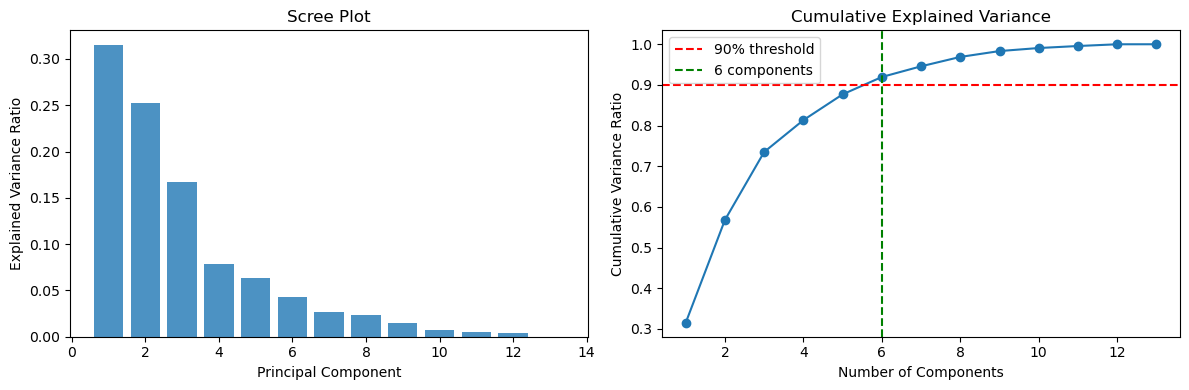

In [30]:
# PCA variance diagnostics
explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)
comps = np.arange(1, len(explained) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(comps, explained, alpha=0.8)
ax[0].set_title("Scree Plot")
ax[0].set_xlabel("Principal Component")
ax[0].set_ylabel("Explained Variance Ratio")

ax[1].plot(comps, cum_explained, marker="o")
ax[1].axhline(0.90, color="red", linestyle="--", label="90% threshold")
ax[1].axvline(n_components_90, color="green", linestyle="--", label=f"{n_components_90} components")
ax[1].set_title("Cumulative Explained Variance")
ax[1].set_xlabel("Number of Components")
ax[1].set_ylabel("Cumulative Variance Ratio")
ax[1].legend()

plt.tight_layout()
plt.show()

## K Selection: Elbow & Silhouette Analysis
Determining optimal number of clusters.

,k,inertia
0,2,38870.609808
1,3,32408.052090
2,4,29095.694813
3,5,26397.382321
4,6,24155.624887
5,7,22673.810544
6,8,21410.398257
7,9,20437.624780
8,10,19562.341589


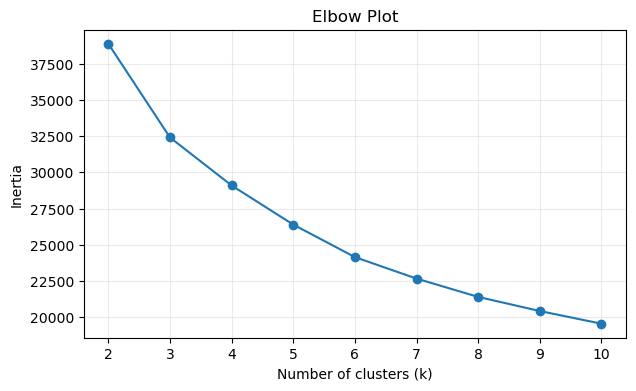

In [31]:
# Elbow curve for k selection
k_values = list(range(2, 11))
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_pca)
    inertias.append(km.inertia_)

elbow_df = pd.DataFrame({"k": k_values, "inertia": inertias})
display(elbow_df)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.xticks(k_values)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot")
plt.grid(alpha=0.25)
plt.show()

,k,silhouette_score
0,2,0.195705
1,3,0.204115
2,4,0.178140
3,5,0.184064
4,6,0.189511
5,7,0.171807
6,8,0.160569
7,9,0.164769
8,10,0.166249


Best k by silhouette: 3 (score=0.2041)


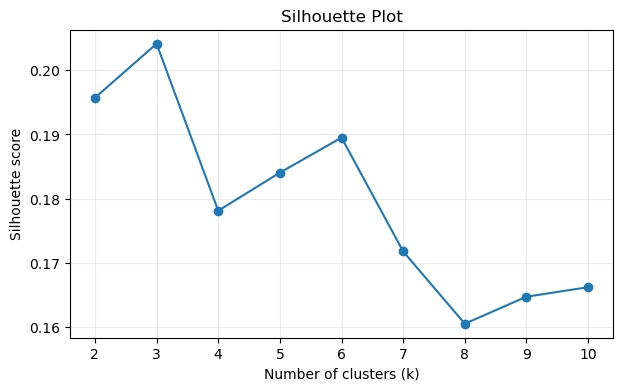

In [32]:
# Silhouette curve for k selection
k_values_sil = list(range(2, 11))
sil_scores = []
for k in k_values_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

sil_df = pd.DataFrame({"k": k_values_sil, "silhouette_score": sil_scores})
display(sil_df)

best_k = int(sil_df.loc[sil_df["silhouette_score"].idxmax(), "k"])
best_score = float(sil_df["silhouette_score"].max())
print(f"Best k by silhouette: {best_k} (score={best_score:.4f})")

plt.figure(figsize=(7, 4))
plt.plot(k_values_sil, sil_scores, marker="o")
plt.xticks(k_values_sil)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Plot")
plt.grid(alpha=0.25)
plt.show()

## Final Clustering & Interpretation
Visualizing and interpreting the final clusters.

Cluster counts:
0    1645
1     651
2    1819
Name: count, dtype: int64


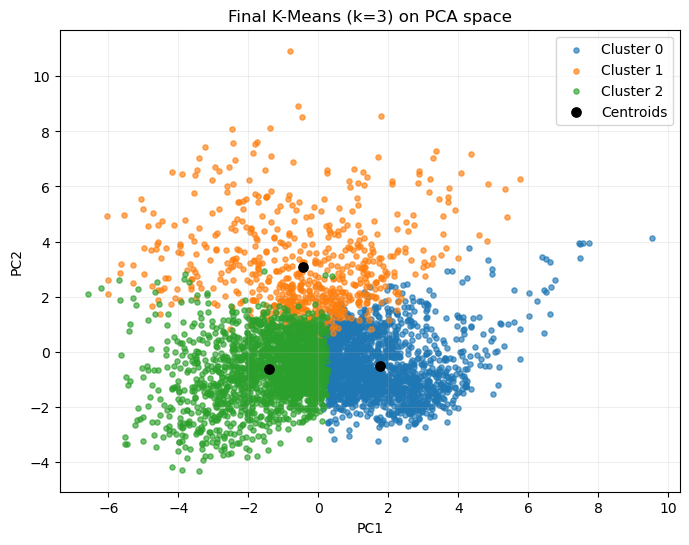

In [33]:
# Final clustering view in PCA space
k_final = 3
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)
labels_final = kmeans_final.fit_predict(X_pca)

cluster_counts = pd.Series(labels_final).value_counts().sort_index()
print("Cluster counts:")
print(cluster_counts)

plt.figure(figsize=(8, 6))
for cl in sorted(np.unique(labels_final)):
    mask = labels_final == cl
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], s=14, alpha=0.65, label=f"Cluster {cl}")

centers_2d = kmeans_final.cluster_centers_[:, :2]
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c="black", s=45, marker="o", label="Centroids")
plt.title("Final K-Means (k=3) on PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Cluster Interpretation
This section summarizes each cluster using mean standardized feature values (z-scores).
- Positive values mean the cluster is above the dataset average for that feature.
- Negative values mean the cluster is below the dataset average for that feature.
- Larger absolute values indicate stronger differences from the overall mean.
The printed lines list the 3 most below-average and 3 most above-average features per cluster, which gives a compact profile for naming and comparing clusters.

In [34]:
# Cluster interpretation via standardized feature means
X_std_df = pd.DataFrame(X, columns=GEO_FEATURES)
concept = X_std_df.groupby(labels_final).mean()
display(concept)

for cl in sorted(concept.index.tolist()):
    s = concept.loc[cl].sort_values()
    low = ", ".join([f"{k} ({v:+.2f})" for k, v in s.head(3).items()])
    high = ", ".join([f"{k} ({v:+.2f})" for k, v in s.tail(3).items()])
    print(f"\nCluster {cl}")
    print(f"  Lower than average:  {low}")
    print(f"  Higher than average: {high}")

,log_num_fields,log_mean_area_sqm,area_cv,coverage,log_fields_per_covered_area,mean_aspect_ratio,largest_field_fraction,mean_compactness,mean_rectangularity,std_rectangularity,prop_rectangular_07,mean_edge_density,mean_cardinal_alignment
0,-0.365097,0.887567,0.030383,0.559437,-0.886570,0.372297,0.235104,-0.428426,0.278237,-0.185435,0.133063,-0.758164,0.501343
1,-1.137500,-1.077962,-0.984658,-1.215105,1.095671,0.233299,1.153645,0.946176,0.484125,-0.928324,0.330074,0.823027,0.312832
2,0.737272,-0.416875,0.324922,-0.071050,0.409635,-0.420179,-0.625492,0.048818,-0.424884,0.499934,-0.238465,0.391088,-0.565345



Cluster 0
  Lower than average:  log_fields_per_covered_area (-0.89), mean_edge_density (-0.76), mean_compactness (-0.43)
  Higher than average: mean_cardinal_alignment (+0.50), coverage (+0.56), log_mean_area_sqm (+0.89)

Cluster 1
  Lower than average:  coverage (-1.22), log_num_fields (-1.14), log_mean_area_sqm (-1.08)
  Higher than average: mean_compactness (+0.95), log_fields_per_covered_area (+1.10), largest_field_fraction (+1.15)

Cluster 2
  Lower than average:  largest_field_fraction (-0.63), mean_cardinal_alignment (-0.57), mean_rectangularity (-0.42)
  Higher than average: log_fields_per_covered_area (+0.41), std_rectangularity (+0.50), log_num_fields (+0.74)
